# Experiment 2: seed sensitivity during training

Thirty-two additional checkpoints repeat the full-update reference (LR 3e-7, L2-SP 0.003, one sample) with training seed 43. Their seed-42 counterparts come from experiment 1. Dataset partitions, monitoring randomness and evaluation folds are fixed. Two seeds provide a paired sensitivity check at this recipe, not a variance estimate for the full grid.

## 0. Evidence and scope

DATA manifests describe progress. Detailed trajectories and benchmark predictions come from project storage. Missing evidence is unavailable, never a zero effect.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from src.visualize import style, campaign as cp, publication as pub, diagnostics as dg
from src.visualize import comparisons as cmp, pilots as pv, optimization as op
from src.visualize.figures import FigureSaver
from src.visualize.inputs import source_description
style.apply()
sink = FigureSaver('experiment2/01_training')
report = cp.NotebookReport('Experiment 2: seed sensitivity during training', sink=sink)
print(source_description())
report.add('0. Evidence and scope', source_description())

DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.


## 1. Reference recipe and training coverage

Track both seeds at the same recipe; completed training does not imply a completed benchmark.

C:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\src\visualize\eval_viz.py:250: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full = pd.concat(frames, ignore_index=True)


C:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\src\visualize\eval_viz.py:250: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full = pd.concat(frames, ignore_index=True)


,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,16,DATA manifests
2,Epoch rows,12592,Project training diagnostics
3,Milestone rows,96,Project trajectory diagnostics
4,Benchmark folds,100,Project final evaluation


,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,16,DATA manifests
2,Epoch rows,12592,Project training diagnostics
3,Milestone rows,96,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


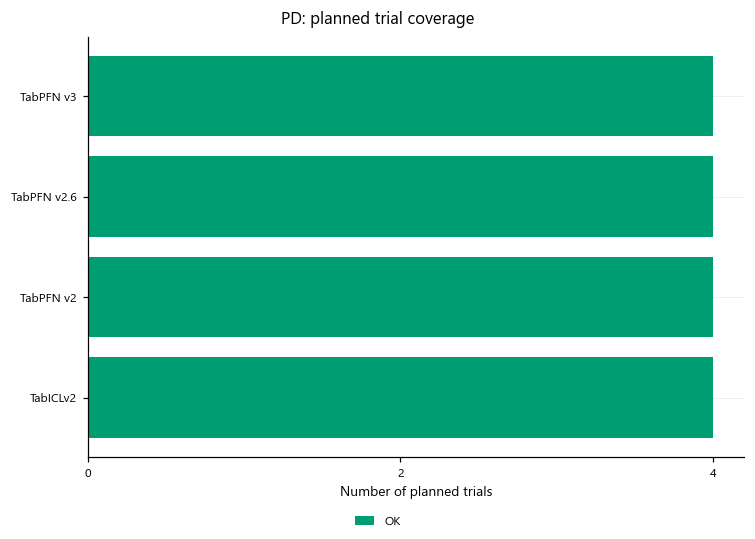

PD. Recorded status of 16 planned PD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,16,DATA manifests
2,Epoch rows,26688,Project training diagnostics
3,Milestone rows,96,Project trajectory diagnostics
4,Benchmark folds,130,Project final evaluation


,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,16,DATA manifests
2,Epoch rows,26688,Project training diagnostics
3,Milestone rows,96,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


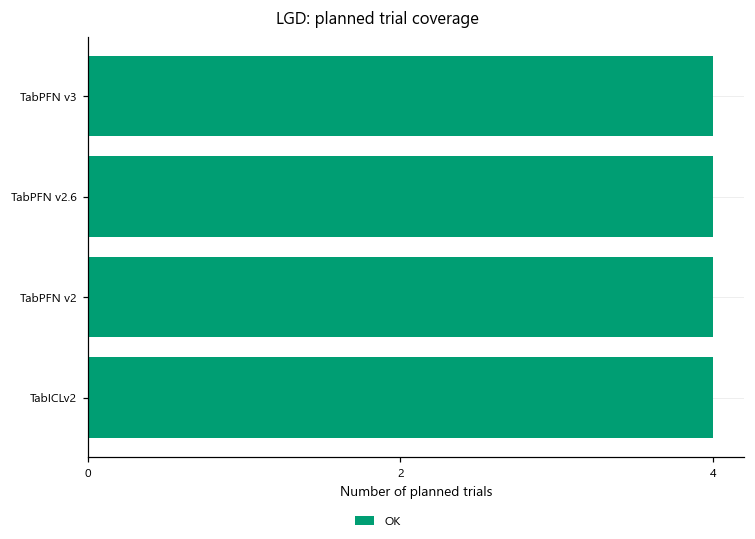

LGD. Recorded status of 16 planned LGD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

In [2]:
main = {track: cmp.reference_campaign(cp.load_campaign(1, track)) for track in ('pd', 'lgd')}
repeat = {track: cp.load_campaign(2, track) for track in ('pd', 'lgd')}
for track in ('pd', 'lgd'):
    report.table(track.upper()+' seed 42 reference evidence', pub.availability(main[track]))
    report.table(track.upper()+' seed 43 evidence', pub.availability(repeat[track]))
    cp.show(sink, cp.plot_coverage(repeat[track]), track=track)
report.add('1. Reference recipe and training coverage', 'Seed 42 reuses the predefined main reference; seed 43 has 16 trials per task. Pending status is not live scheduler state.')

## 2. Paired loss and optimization dynamics

Compare the two seeds on the native data loss, gradients, clipping and anchored parameter drift. Loss excludes L2-SP; objective scales differ between model families.

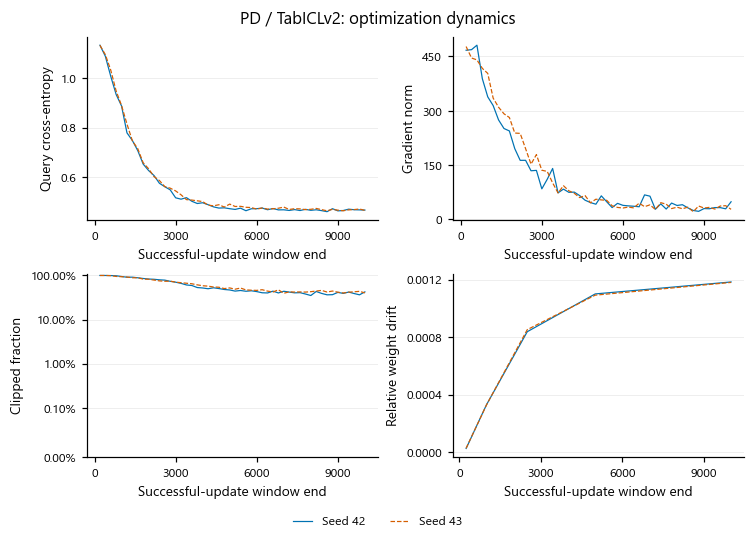

PD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

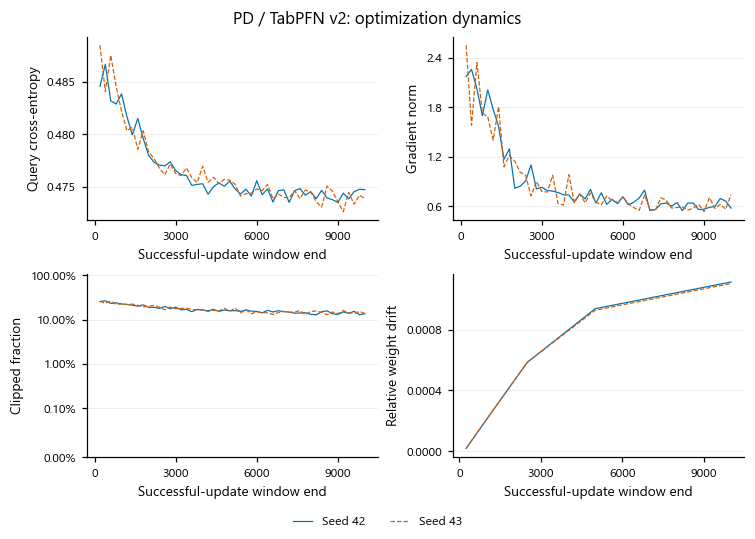

PD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

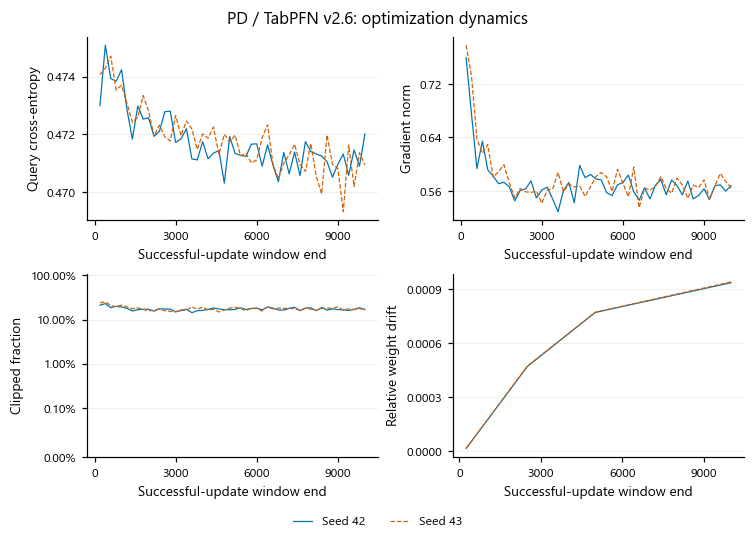

PD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

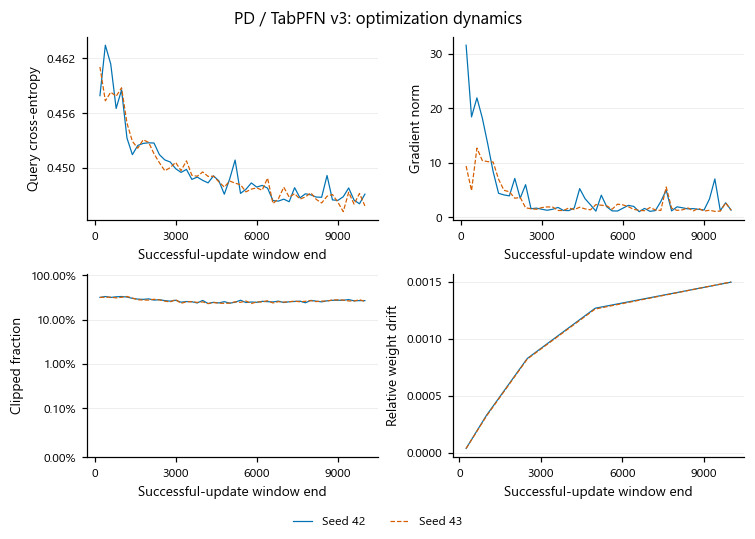

PD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

,base,learning_rate,l2sp_lambda,frozen,sampling,partition,seed,epochs,nonfinite_diagnostics,peak_epoch_gradient,peak_epoch_clipped_fraction,peak_l2sp_penalty,amp_skips,data_skips,peak_weight_drift
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,42,770,0,7.430767,0.384615,0.000086,0,0,0.001053
1,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,42,770,0,0.974824,0.384615,0.000090,0,0,0.000922
2,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,42,770,0,369.526923,0.461538,0.000184,0,0,0.001484
3,TabICLv2,3.000000e-07,0.003,False,one_sample,0,42,770,0,775.895209,1.000000,0.000565,0,0,0.001127
4,TabPFN v2,3.000000e-07,0.003,False,one_sample,1,42,770,0,10.486227,0.461538,0.000098,0,0,0.001126
5,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1,42,770,0,1.532684,1.000000,0.000095,0,0,0.000949
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,1,42,770,0,203.517912,0.666667,0.000189,0,0,0.001504
7,TabICLv2,3.000000e-07,0.003,False,one_sample,1,42,770,0,1190.197642,1.000000,0.000627,0,0,0.001188
8,TabPFN v2,3.000000e-07,0.003,False,one_sample,2,42,834,0,9.174893,0.583333,0.000095,0,0,0.001111
9,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,2,42,834,0,1.186310,0.416667,0.000081,0,0,0.000877


,trial_name,base,learning_rate,l2sp_lambda,frozen,sampling,recorded_epochs,full_coverage_epochs,fullest_observed_tables,min_observed_tables,last_update,partial_coverage_epochs
0,cpt_main_v5_s00_pd_tabicl-classifier-v2-202602...,TabICLv2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
1,cpt_main_v5_s00_pd_tabpfn-v2-classifier-v2_def...,TabPFN v2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
2,cpt_main_v5_s00_pd_tabpfn-v2.6-classifier-v2.6...,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
3,cpt_main_v5_s00_pd_tabpfn-v3-classifier-v3_def...,TabPFN v3,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
4,cpt_main_v5_s01_pd_tabicl-classifier-v2-202602...,TabICLv2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
5,cpt_main_v5_s01_pd_tabpfn-v2-classifier-v2_def...,TabPFN v2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
6,cpt_main_v5_s01_pd_tabpfn-v2.6-classifier-v2.6...,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
7,cpt_main_v5_s01_pd_tabpfn-v3-classifier-v3_def...,TabPFN v3,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
8,cpt_main_v5_s02_pd_tabicl-classifier-v2-202602...,TabICLv2,3.000000e-07,0.003,False,one_sample,834,833,12,4,10000,1
9,cpt_main_v5_s02_pd_tabpfn-v2-classifier-v2_def...,TabPFN v2,3.000000e-07,0.003,False,one_sample,834,833,12,4,10000,1


,trial_name,successful_updates,train_loss,observed_tables,full_observed_tables,complete_pass,base,learning_rate,l2sp_lambda,frozen,sampling
0,cpt_main_v5_s00_pd_tabicl-classifier-v2-202602...,10000,0.598187,3,13,False,TabICLv2,3.000000e-07,0.003,False,one_sample
1,cpt_main_v5_s00_pd_tabpfn-v2-classifier-v2_def...,10000,0.529551,3,13,False,TabPFN v2,3.000000e-07,0.003,False,one_sample
2,cpt_main_v5_s00_pd_tabpfn-v2.6-classifier-v2.6...,10000,0.530151,3,13,False,TabPFN v2.6,3.000000e-07,0.003,False,one_sample
3,cpt_main_v5_s00_pd_tabpfn-v3-classifier-v3_def...,10000,0.517466,3,13,False,TabPFN v3,3.000000e-07,0.003,False,one_sample
4,cpt_main_v5_s01_pd_tabicl-classifier-v2-202602...,10000,0.351242,3,13,False,TabICLv2,3.000000e-07,0.003,False,one_sample
5,cpt_main_v5_s01_pd_tabpfn-v2-classifier-v2_def...,10000,0.387154,3,13,False,TabPFN v2,3.000000e-07,0.003,False,one_sample
6,cpt_main_v5_s01_pd_tabpfn-v2.6-classifier-v2.6...,10000,0.388320,3,13,False,TabPFN v2.6,3.000000e-07,0.003,False,one_sample
7,cpt_main_v5_s01_pd_tabpfn-v3-classifier-v3_def...,10000,0.329108,3,13,False,TabPFN v3,3.000000e-07,0.003,False,one_sample
8,cpt_main_v5_s02_pd_tabicl-classifier-v2-202602...,10000,0.514049,4,12,False,TabICLv2,3.000000e-07,0.003,False,one_sample
9,cpt_main_v5_s02_pd_tabpfn-v2-classifier-v2_def...,10000,0.520873,4,12,False,TabPFN v2,3.000000e-07,0.003,False,one_sample


,base,learning_rate,l2sp_lambda,frozen,sampling,partition,seed,epochs,nonfinite_diagnostics,peak_epoch_gradient,peak_epoch_clipped_fraction,peak_l2sp_penalty,amp_skips,data_skips,peak_weight_drift
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,43,770,0,11.250925,0.384615,0.000085,0,0,0.001048
1,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,43,770,0,1.083498,0.384615,0.000088,0,0,0.000917
2,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,43,770,0,123.305995,0.538462,0.000184,0,0,0.001486
3,TabICLv2,3.000000e-07,0.003,False,one_sample,0,43,770,0,959.497094,1.000000,0.000567,0,0,0.001129
4,TabPFN v2,3.000000e-07,0.003,False,one_sample,1,43,770,0,8.762692,0.461538,0.000097,0,0,0.001122
5,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1,43,770,0,1.193056,0.666667,0.000098,0,0,0.000963
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,1,43,770,0,292.395383,0.666667,0.000190,0,0,0.001509
7,TabICLv2,3.000000e-07,0.003,False,one_sample,1,43,770,0,983.612189,1.000000,0.000715,0,0,0.001268
8,TabPFN v2,3.000000e-07,0.003,False,one_sample,2,43,834,0,11.781260,0.500000,0.000093,0,0,0.001097
9,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,2,43,834,0,1.407099,0.500000,0.000082,0,0,0.000883


,trial_name,base,learning_rate,l2sp_lambda,frozen,sampling,recorded_epochs,full_coverage_epochs,fullest_observed_tables,min_observed_tables,last_update,partial_coverage_epochs
0,cpt_seeds_v5_s00_pd_tabicl-classifier-v2-20260...,TabICLv2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
1,cpt_seeds_v5_s00_pd_tabpfn-v2-classifier-v2_de...,TabPFN v2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
2,cpt_seeds_v5_s00_pd_tabpfn-v2.6-classifier-v2....,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
3,cpt_seeds_v5_s00_pd_tabpfn-v3-classifier-v3_de...,TabPFN v3,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
4,cpt_seeds_v5_s01_pd_tabicl-classifier-v2-20260...,TabICLv2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
5,cpt_seeds_v5_s01_pd_tabpfn-v2-classifier-v2_de...,TabPFN v2,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
6,cpt_seeds_v5_s01_pd_tabpfn-v2.6-classifier-v2....,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
7,cpt_seeds_v5_s01_pd_tabpfn-v3-classifier-v3_de...,TabPFN v3,3.000000e-07,0.003,False,one_sample,770,769,13,3,10000,1
8,cpt_seeds_v5_s02_pd_tabicl-classifier-v2-20260...,TabICLv2,3.000000e-07,0.003,False,one_sample,834,833,12,4,10000,1
9,cpt_seeds_v5_s02_pd_tabpfn-v2-classifier-v2_de...,TabPFN v2,3.000000e-07,0.003,False,one_sample,834,833,12,4,10000,1


,trial_name,successful_updates,train_loss,observed_tables,full_observed_tables,complete_pass,base,learning_rate,l2sp_lambda,frozen,sampling
0,cpt_seeds_v5_s00_pd_tabicl-classifier-v2-20260...,10000,0.506337,3,13,False,TabICLv2,3.000000e-07,0.003,False,one_sample
1,cpt_seeds_v5_s00_pd_tabpfn-v2-classifier-v2_de...,10000,0.435526,3,13,False,TabPFN v2,3.000000e-07,0.003,False,one_sample
2,cpt_seeds_v5_s00_pd_tabpfn-v2.6-classifier-v2....,10000,0.429607,3,13,False,TabPFN v2.6,3.000000e-07,0.003,False,one_sample
3,cpt_seeds_v5_s00_pd_tabpfn-v3-classifier-v3_de...,10000,0.380231,3,13,False,TabPFN v3,3.000000e-07,0.003,False,one_sample
4,cpt_seeds_v5_s01_pd_tabicl-classifier-v2-20260...,10000,0.433237,3,13,False,TabICLv2,3.000000e-07,0.003,False,one_sample
5,cpt_seeds_v5_s01_pd_tabpfn-v2-classifier-v2_de...,10000,0.448129,3,13,False,TabPFN v2,3.000000e-07,0.003,False,one_sample
6,cpt_seeds_v5_s01_pd_tabpfn-v2.6-classifier-v2....,10000,0.441678,3,13,False,TabPFN v2.6,3.000000e-07,0.003,False,one_sample
7,cpt_seeds_v5_s01_pd_tabpfn-v3-classifier-v3_de...,10000,0.418601,3,13,False,TabPFN v3,3.000000e-07,0.003,False,one_sample
8,cpt_seeds_v5_s02_pd_tabicl-classifier-v2-20260...,10000,0.506165,4,12,False,TabICLv2,3.000000e-07,0.003,False,one_sample
9,cpt_seeds_v5_s02_pd_tabpfn-v2-classifier-v2_de...,10000,0.525065,4,12,False,TabPFN v2,3.000000e-07,0.003,False,one_sample


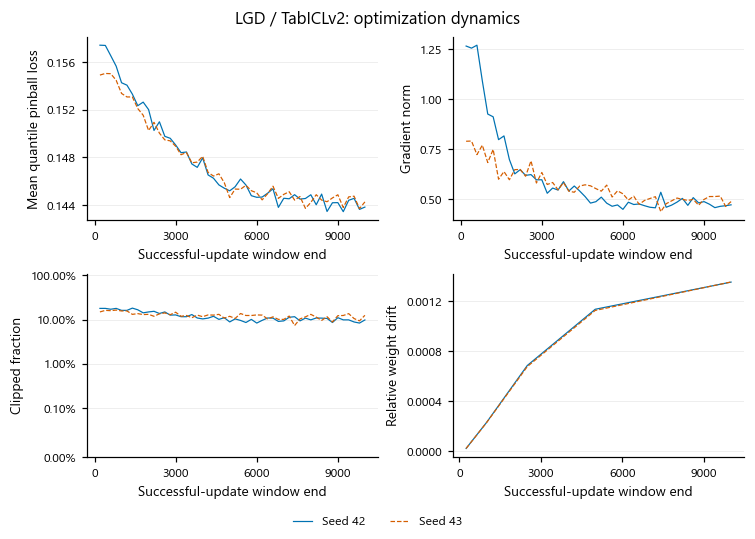

LGD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

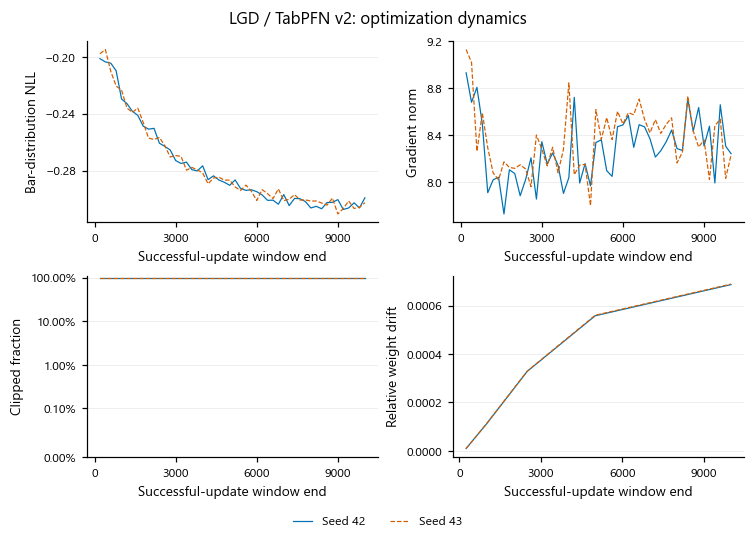

LGD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

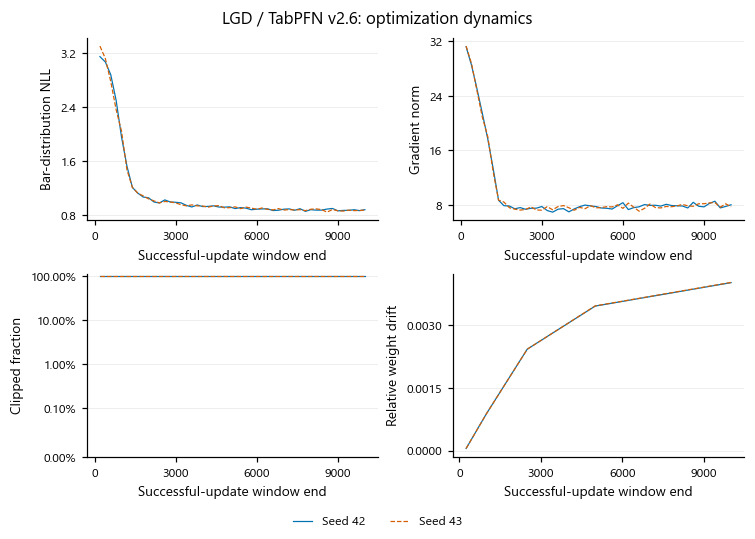

LGD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

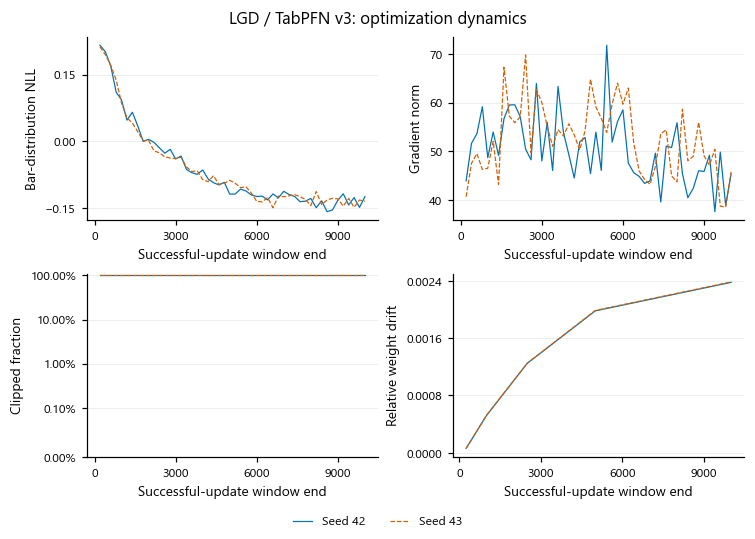

LGD. Optimization diagnostics at the fixed reference recipe. Each curve is the median of trial-window means for each displayed training seed and sampling protocol across available dataset partitions; counts are retained in the text. Incomplete table-coverage loss epochs are tabulated separately; missing windows remain gaps. Clipping uses a shared percentage range, linear through 0.1% and logarithmic above. Drift follows exact measured milestones. Loss excludes L2-SP and retains the native objective scale, which is not comparable across architectures.

,base,learning_rate,l2sp_lambda,frozen,sampling,partition,seed,epochs,nonfinite_diagnostics,peak_epoch_gradient,peak_epoch_clipped_fraction,peak_l2sp_penalty,amp_skips,data_skips,peak_weight_drift
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,42,1667,0,19.063607,1.000000,0.000240,0,0,0.000655
1,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,42,1667,0,39.263884,1.000000,0.001691,0,0,0.004031
2,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,42,1667,0,538.965864,1.000000,0.000887,0,0,0.002386
3,TabICLv2,3.000000e-07,0.003,False,one_sample,0,42,1667,0,3.296418,0.500000,0.000573,0,0,0.001393
4,TabPFN v2,3.000000e-07,0.003,False,one_sample,1,42,1667,0,16.504884,1.000000,0.000264,0,0,0.000688
5,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1,42,1667,0,38.533919,1.000000,0.001781,0,0,0.004137
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,1,42,1667,0,961.438830,1.000000,0.000881,0,0,0.002378
7,TabICLv2,3.000000e-07,0.003,False,one_sample,1,42,1667,0,1.369637,0.500000,0.000459,0,0,0.001245
8,TabPFN v2,3.000000e-07,0.003,False,one_sample,2,42,1667,0,23.456835,1.000000,0.000262,0,0,0.000686
9,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,2,42,1667,0,38.840819,1.000000,0.001559,0,0,0.003871


,trial_name,base,learning_rate,l2sp_lambda,frozen,sampling,recorded_epochs,full_coverage_epochs,fullest_observed_tables,min_observed_tables,last_update,partial_coverage_epochs
0,cpt_main_v5_s00_lgd_tabicl-regressor-v2-202602...,TabICLv2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
1,cpt_main_v5_s00_lgd_tabpfn-v2-regressor-v2_def...,TabPFN v2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
2,cpt_main_v5_s00_lgd_tabpfn-v2.6-regressor-v2.6...,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
3,cpt_main_v5_s00_lgd_tabpfn-v3-regressor-v3_def...,TabPFN v3,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
4,cpt_main_v5_s01_lgd_tabicl-regressor-v2-202602...,TabICLv2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
5,cpt_main_v5_s01_lgd_tabpfn-v2-regressor-v2_def...,TabPFN v2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
6,cpt_main_v5_s01_lgd_tabpfn-v2.6-regressor-v2.6...,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
7,cpt_main_v5_s01_lgd_tabpfn-v3-regressor-v3_def...,TabPFN v3,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
8,cpt_main_v5_s02_lgd_tabicl-regressor-v2-202602...,TabICLv2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
9,cpt_main_v5_s02_lgd_tabpfn-v2-regressor-v2_def...,TabPFN v2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1


,trial_name,successful_updates,train_loss,observed_tables,full_observed_tables,complete_pass,base,learning_rate,l2sp_lambda,frozen,sampling
0,cpt_main_v5_s00_lgd_tabicl-regressor-v2-202602...,10000,0.123964,4,6,False,TabICLv2,3.000000e-07,0.003,False,one_sample
1,cpt_main_v5_s00_lgd_tabpfn-v2-regressor-v2_def...,10000,-0.593957,4,6,False,TabPFN v2,3.000000e-07,0.003,False,one_sample
2,cpt_main_v5_s00_lgd_tabpfn-v2.6-regressor-v2.6...,10000,0.669583,4,6,False,TabPFN v2.6,3.000000e-07,0.003,False,one_sample
3,cpt_main_v5_s00_lgd_tabpfn-v3-regressor-v3_def...,10000,-0.476520,4,6,False,TabPFN v3,3.000000e-07,0.003,False,one_sample
4,cpt_main_v5_s01_lgd_tabicl-regressor-v2-202602...,10000,0.133741,4,6,False,TabICLv2,3.000000e-07,0.003,False,one_sample
5,cpt_main_v5_s01_lgd_tabpfn-v2-regressor-v2_def...,10000,-0.041666,4,6,False,TabPFN v2,3.000000e-07,0.003,False,one_sample
6,cpt_main_v5_s01_lgd_tabpfn-v2.6-regressor-v2.6...,10000,0.765556,4,6,False,TabPFN v2.6,3.000000e-07,0.003,False,one_sample
7,cpt_main_v5_s01_lgd_tabpfn-v3-regressor-v3_def...,10000,0.062051,4,6,False,TabPFN v3,3.000000e-07,0.003,False,one_sample
8,cpt_main_v5_s02_lgd_tabicl-regressor-v2-202602...,10000,0.138814,4,6,False,TabICLv2,3.000000e-07,0.003,False,one_sample
9,cpt_main_v5_s02_lgd_tabpfn-v2-regressor-v2_def...,10000,-0.272492,4,6,False,TabPFN v2,3.000000e-07,0.003,False,one_sample


,base,learning_rate,l2sp_lambda,frozen,sampling,partition,seed,epochs,nonfinite_diagnostics,peak_epoch_gradient,peak_epoch_clipped_fraction,peak_l2sp_penalty,amp_skips,data_skips,peak_weight_drift
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,43,1667,0,26.912418,1.000000,0.000242,0,0,0.000659
1,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,43,1667,0,43.380729,1.000000,0.001686,0,0,0.004025
2,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,43,1667,0,361.156663,1.000000,0.000889,0,0,0.002388
3,TabICLv2,3.000000e-07,0.003,False,one_sample,0,43,1667,0,2.647040,0.500000,0.000568,0,0,0.001385
4,TabPFN v2,3.000000e-07,0.003,False,one_sample,1,43,1667,0,18.651300,1.000000,0.000266,0,0,0.000690
5,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1,43,1667,0,57.134434,1.000000,0.001785,0,0,0.004142
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,1,43,1667,0,133.503076,1.000000,0.000911,0,0,0.002418
7,TabICLv2,3.000000e-07,0.003,False,one_sample,1,43,1667,0,1.832413,0.333333,0.000462,0,0,0.001249
8,TabPFN v2,3.000000e-07,0.003,False,one_sample,2,43,1667,0,20.534187,1.000000,0.000264,0,0,0.000688
9,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,2,43,1667,0,38.841991,1.000000,0.001569,0,0,0.003883


,trial_name,base,learning_rate,l2sp_lambda,frozen,sampling,recorded_epochs,full_coverage_epochs,fullest_observed_tables,min_observed_tables,last_update,partial_coverage_epochs
0,cpt_seeds_v5_s00_lgd_tabicl-regressor-v2-20260...,TabICLv2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
1,cpt_seeds_v5_s00_lgd_tabpfn-v2-regressor-v2_de...,TabPFN v2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
2,cpt_seeds_v5_s00_lgd_tabpfn-v2.6-regressor-v2....,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
3,cpt_seeds_v5_s00_lgd_tabpfn-v3-regressor-v3_de...,TabPFN v3,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
4,cpt_seeds_v5_s01_lgd_tabicl-regressor-v2-20260...,TabICLv2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
5,cpt_seeds_v5_s01_lgd_tabpfn-v2-regressor-v2_de...,TabPFN v2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
6,cpt_seeds_v5_s01_lgd_tabpfn-v2.6-regressor-v2....,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
7,cpt_seeds_v5_s01_lgd_tabpfn-v3-regressor-v3_de...,TabPFN v3,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
8,cpt_seeds_v5_s02_lgd_tabicl-regressor-v2-20260...,TabICLv2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1
9,cpt_seeds_v5_s02_lgd_tabpfn-v2-regressor-v2_de...,TabPFN v2,3.000000e-07,0.003,False,one_sample,1667,1666,6,4,10000,1


,trial_name,successful_updates,train_loss,observed_tables,full_observed_tables,complete_pass,base,learning_rate,l2sp_lambda,frozen,sampling
0,cpt_seeds_v5_s00_lgd_tabicl-regressor-v2-20260...,10000,0.153585,4,6,False,TabICLv2,3.000000e-07,0.003,False,one_sample
1,cpt_seeds_v5_s00_lgd_tabpfn-v2-regressor-v2_de...,10000,-0.552729,4,6,False,TabPFN v2,3.000000e-07,0.003,False,one_sample
2,cpt_seeds_v5_s00_lgd_tabpfn-v2.6-regressor-v2....,10000,0.916976,4,6,False,TabPFN v2.6,3.000000e-07,0.003,False,one_sample
3,cpt_seeds_v5_s00_lgd_tabpfn-v3-regressor-v3_de...,10000,-0.370844,4,6,False,TabPFN v3,3.000000e-07,0.003,False,one_sample
4,cpt_seeds_v5_s01_lgd_tabicl-regressor-v2-20260...,10000,0.162193,4,6,False,TabICLv2,3.000000e-07,0.003,False,one_sample
5,cpt_seeds_v5_s01_lgd_tabpfn-v2-regressor-v2_de...,10000,-0.172573,4,6,False,TabPFN v2,3.000000e-07,0.003,False,one_sample
6,cpt_seeds_v5_s01_lgd_tabpfn-v2.6-regressor-v2....,10000,0.809402,4,6,False,TabPFN v2.6,3.000000e-07,0.003,False,one_sample
7,cpt_seeds_v5_s01_lgd_tabpfn-v3-regressor-v3_de...,10000,-0.008206,4,6,False,TabPFN v3,3.000000e-07,0.003,False,one_sample
8,cpt_seeds_v5_s02_lgd_tabicl-regressor-v2-20260...,10000,0.144344,4,6,False,TabICLv2,3.000000e-07,0.003,False,one_sample
9,cpt_seeds_v5_s02_lgd_tabpfn-v2-regressor-v2_de...,10000,-0.548983,4,6,False,TabPFN v2,3.000000e-07,0.003,False,one_sample


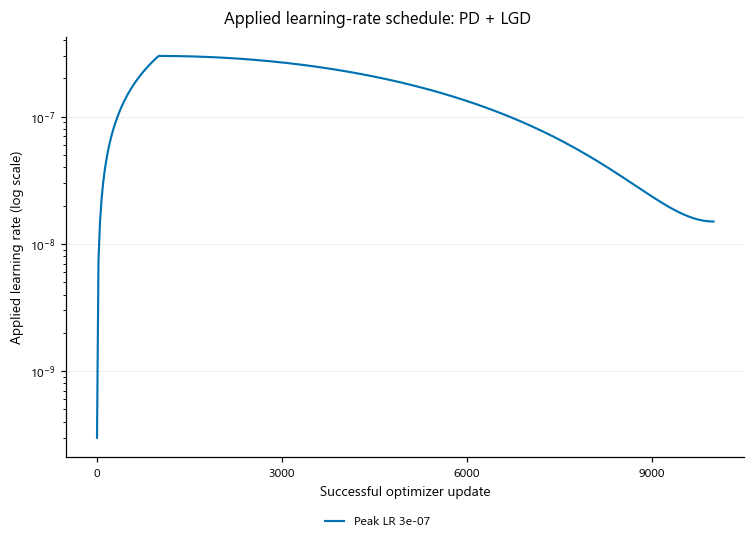

Learning rates evaluated from the recorded campaign configuration using the training scheduler. Each distinct peak-rate schedule is drawn once, pooling tasks only when budget, warmup and decay floor agree. The rate for update u is the scheduler value before that update (index u minus one). The first update has zero learning rate and is omitted from the logarithmic axis, but retained in the table. These are configured schedules; measured epoch-end rates and their sampling intervals are reported separately.

In [3]:
for track in ('pd','lgd'):
    cp.show(sink, pv.plot_process_overview(repeat[track], reference=main[track]), track=track)
    for seed, run in ((42, main[track]), (43, repeat[track])):
        report.table(track.upper()+f' seed {seed} numerical health', pv.health_table(run))
        for label, frame in cp.loss_coverage_tables(run).items():
            report.table(track.upper()+f' seed {seed} '+label, frame)
cp.show(sink, pv.plot_schedule(list(repeat.values())))
report.add('2. Paired loss and optimization dynamics', 'Window counts identify partial evidence. Partial table traversals are not joined into full-corpus loss curves. Both seeds use the same configured learning-rate schedule.')

## 3. Credit transfer and non-credit retention through training

Pair seeds within dataset and training partition before averaging. Positive differences favor seed 43; they are not the absolute benefit of adaptation.

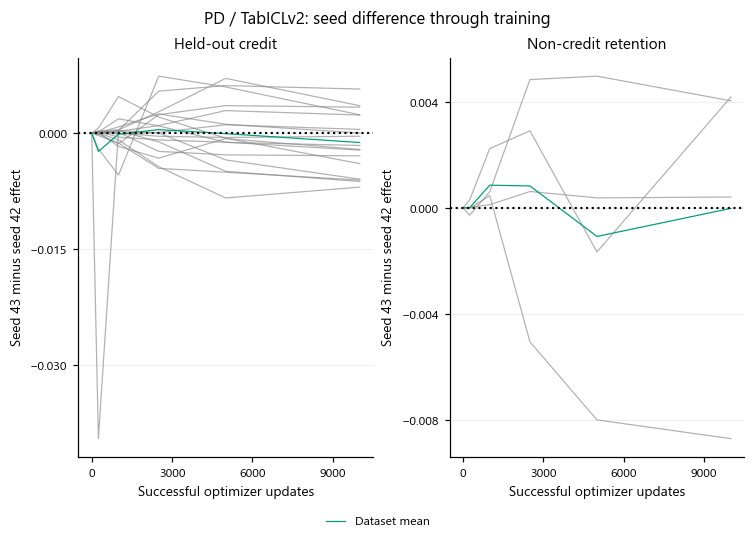

PD. Matched seed differences in fixed-update monitoring effects. Thin gray lines show datasets; the colored mean retains the same baseline dataset support at every milestone. Non-credit dataset effects require all four matched training partitions. Gaps remain gaps; these are small-context monitors, separate from the final five-fold benchmark.

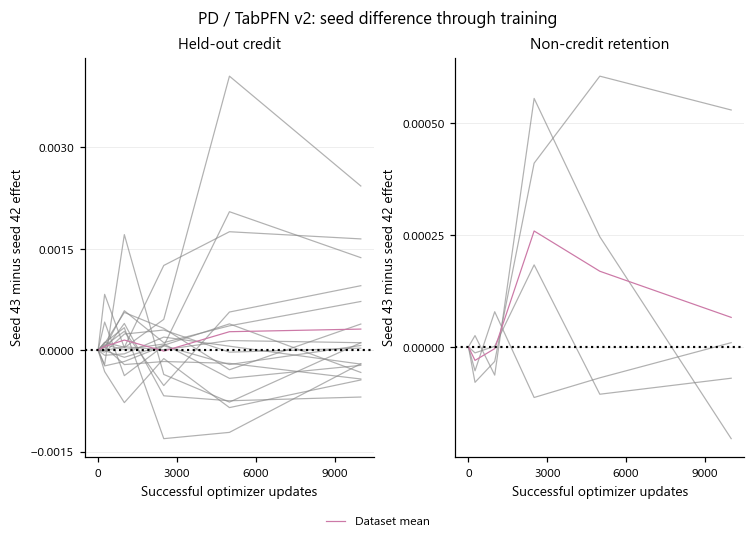

PD. Matched seed differences in fixed-update monitoring effects. Thin gray lines show datasets; the colored mean retains the same baseline dataset support at every milestone. Non-credit dataset effects require all four matched training partitions. Gaps remain gaps; these are small-context monitors, separate from the final five-fold benchmark.

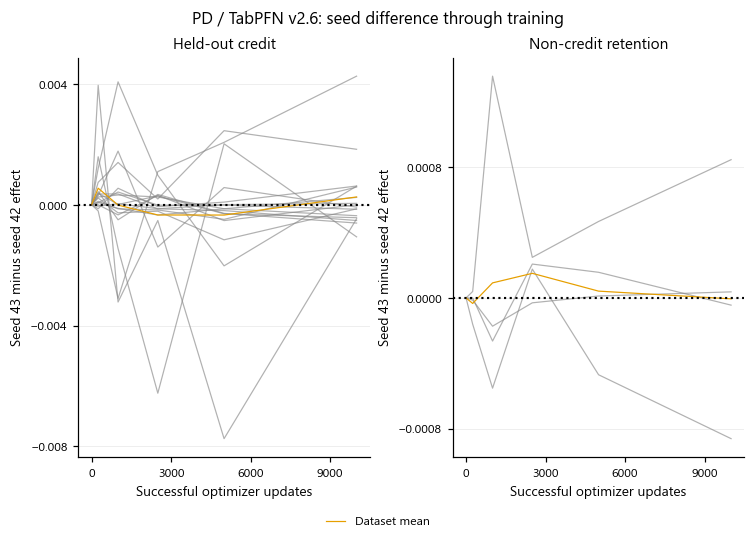

PD. Matched seed differences in fixed-update monitoring effects. Thin gray lines show datasets; the colored mean retains the same baseline dataset support at every milestone. Non-credit dataset effects require all four matched training partitions. Gaps remain gaps; these are small-context monitors, separate from the final five-fold benchmark.

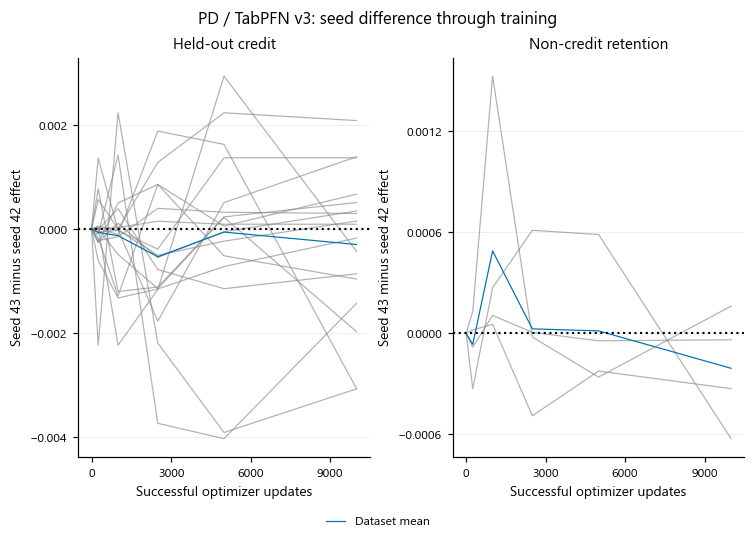

PD. Matched seed differences in fixed-update monitoring effects. Thin gray lines show datasets; the colored mean retains the same baseline dataset support at every milestone. Non-credit dataset effects require all four matched training partitions. Gaps remain gaps; these are small-context monitors, separate from the final five-fold benchmark.

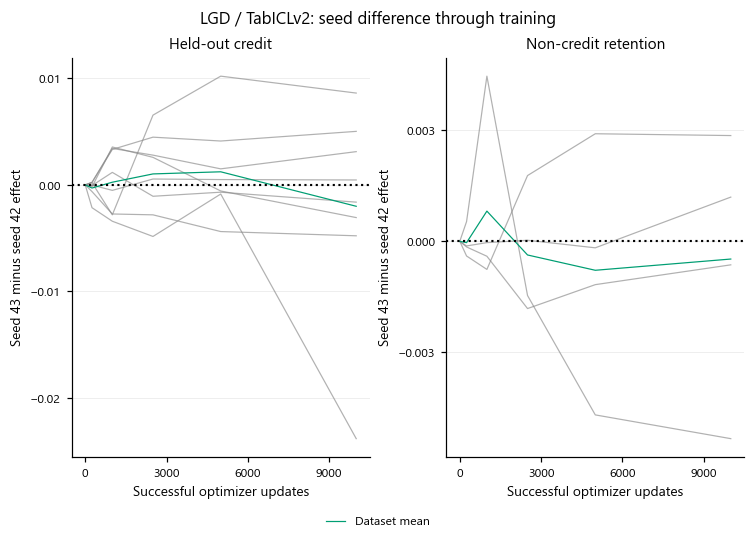

LGD. Matched seed differences in fixed-update monitoring effects. Thin gray lines show datasets; the colored mean retains the same baseline dataset support at every milestone. Non-credit dataset effects require all four matched training partitions. Gaps remain gaps; these are small-context monitors, separate from the final five-fold benchmark.

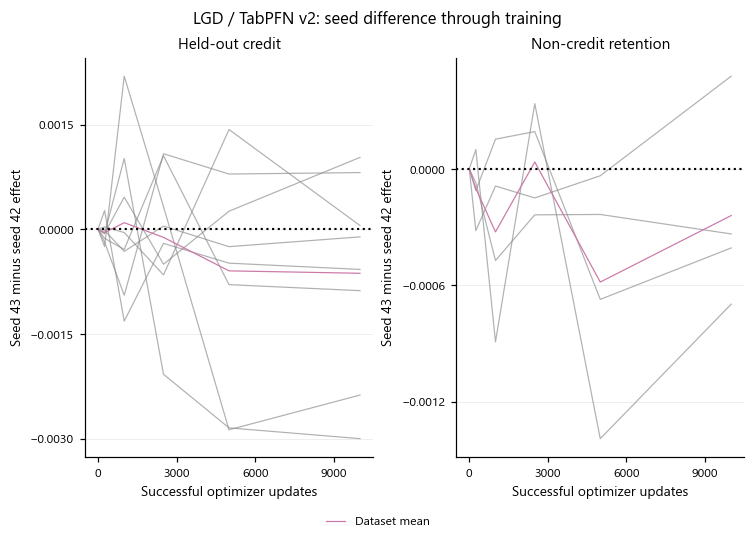

LGD. Matched seed differences in fixed-update monitoring effects. Thin gray lines show datasets; the colored mean retains the same baseline dataset support at every milestone. Non-credit dataset effects require all four matched training partitions. Gaps remain gaps; these are small-context monitors, separate from the final five-fold benchmark.

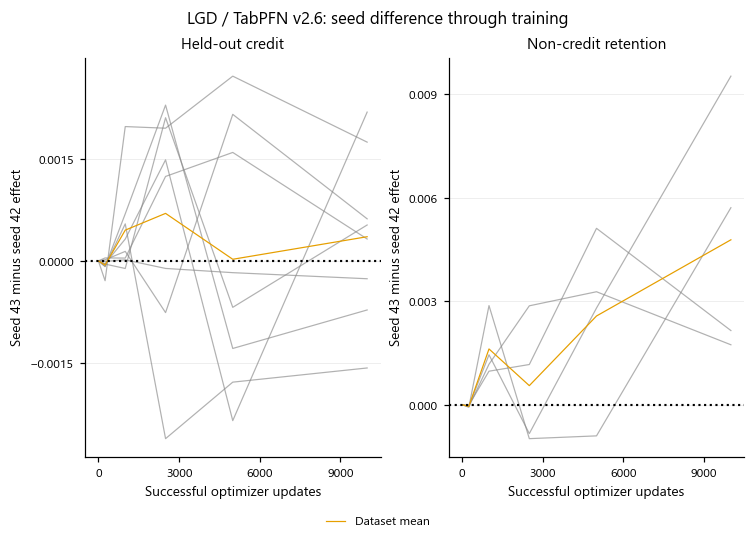

LGD. Matched seed differences in fixed-update monitoring effects. Thin gray lines show datasets; the colored mean retains the same baseline dataset support at every milestone. Non-credit dataset effects require all four matched training partitions. Gaps remain gaps; these are small-context monitors, separate from the final five-fold benchmark.

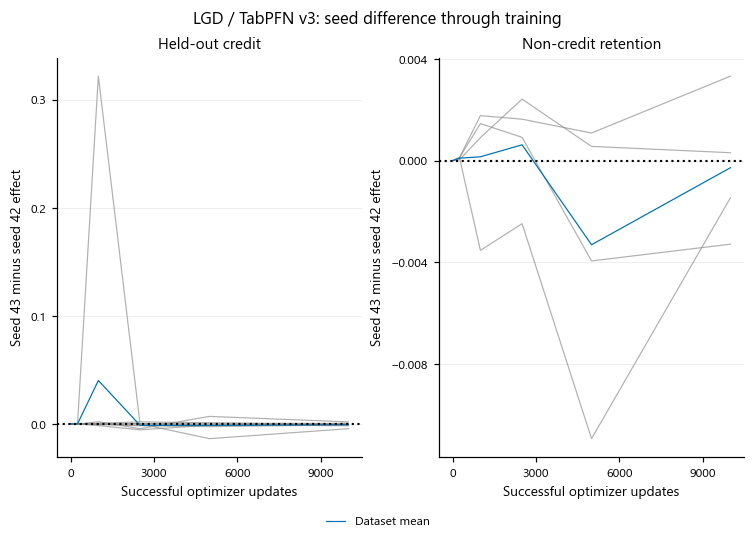

LGD. Matched seed differences in fixed-update monitoring effects. Thin gray lines show datasets; the colored mean retains the same baseline dataset support at every milestone. Non-credit dataset effects require all four matched training partitions. Gaps remain gaps; these are small-context monitors, separate from the final five-fold benchmark.

In [4]:
for track in ('pd','lgd'):
    cp.show(sink, cmp.plot_seed_curves(main[track], repeat[track]), track=track)
report.add('3. Credit transfer and non-credit retention through training', 'Non-credit curves require all four matched partitions per dataset and retain the baseline dataset cohort. These small-context monitors are separate from final five-fold evaluation.')

## 4. Resources and matched training costs

Retain the observed time, row exposure, memory and parameter movement for both seeds.

,base,learning_rate,l2sp_lambda,frozen,sampling,partition,gpu_hours_seed42,rows_seen_seed42,sec_per_step_seed42,peak_gpu_gb_seed42,final_drift_seed42,gpu_hours_seed43,rows_seen_seed43,sec_per_step_seed43,peak_gpu_gb_seed43,final_drift_seed43
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,1.454035,84373151,0.523453,181.083,0.001053,1.462365,84373151,0.526452,181.083,0.001048
1,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,1.257469,91297151,0.452689,128.420,0.000922,1.266915,91297151,0.456089,128.420,0.000917
2,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,1.558402,195157151,0.561025,121.097,0.001484,1.544833,195157151,0.556140,121.097,0.001486
3,TabICLv2,3.000000e-07,0.003,False,one_sample,0,1.723669,195157151,0.620521,27.121,0.001127,1.742087,195157151,0.627151,27.121,0.001129
4,TabPFN v2,3.000000e-07,0.003,False,one_sample,1,1.509654,81431410,0.543475,181.083,0.001126,1.498518,81431410,0.539467,181.083,0.001122
5,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1,1.267968,87585410,0.456468,128.420,0.000949,1.255736,87585410,0.452065,128.420,0.000963
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,1,1.528158,179895410,0.550137,121.097,0.001504,1.513583,179895410,0.544890,121.097,0.001509
7,TabICLv2,3.000000e-07,0.003,False,one_sample,1,1.675400,179895410,0.603144,27.121,0.001188,1.679518,179895410,0.604627,27.121,0.001268
8,TabPFN v2,3.000000e-07,0.003,False,one_sample,2,1.326894,74887937,0.477682,181.083,0.001111,1.341781,74896712,0.483041,181.083,0.001097
9,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,2,1.148323,80721937,0.413396,128.420,0.000877,1.161091,80731712,0.417993,128.420,0.000883


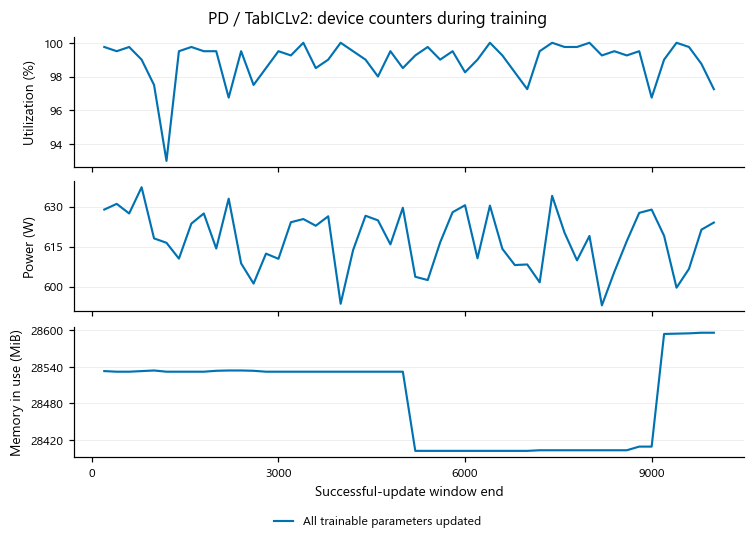

PD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

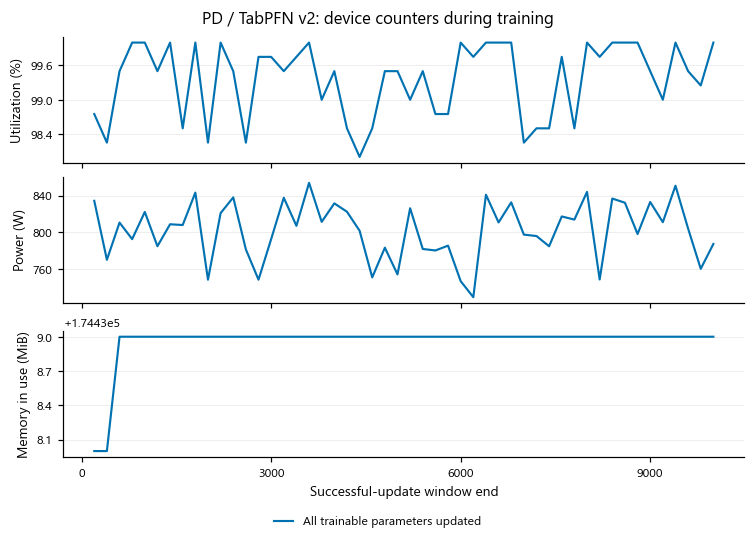

PD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

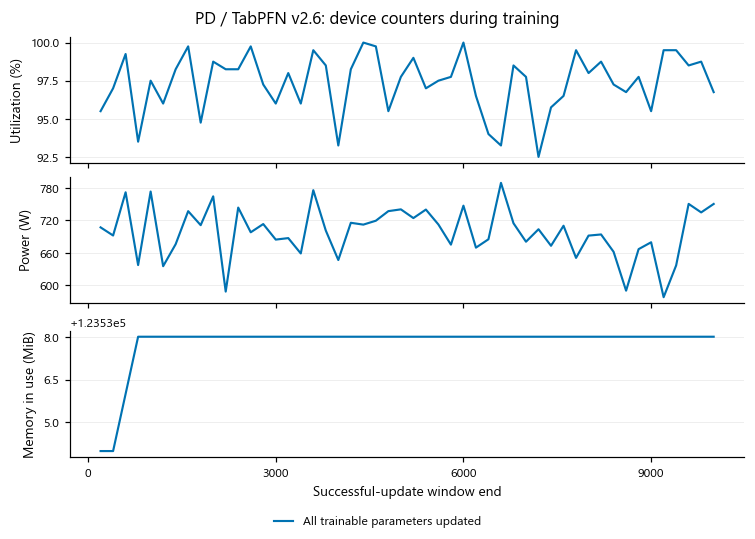

PD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

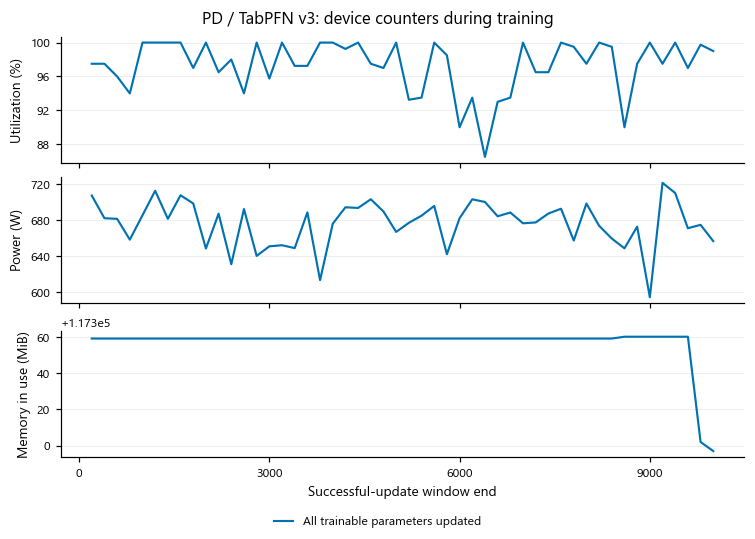

PD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

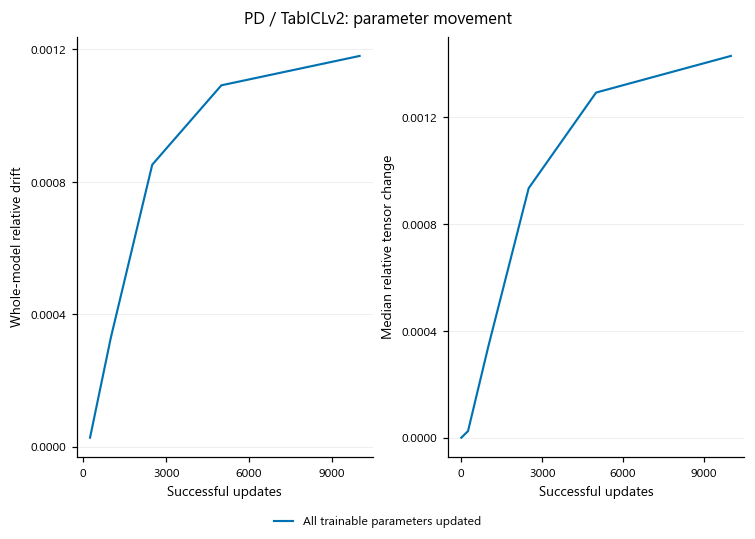

PD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

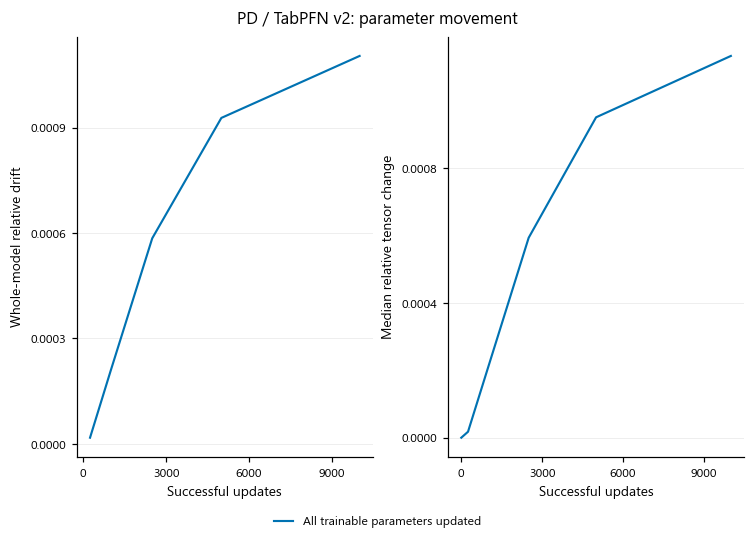

PD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

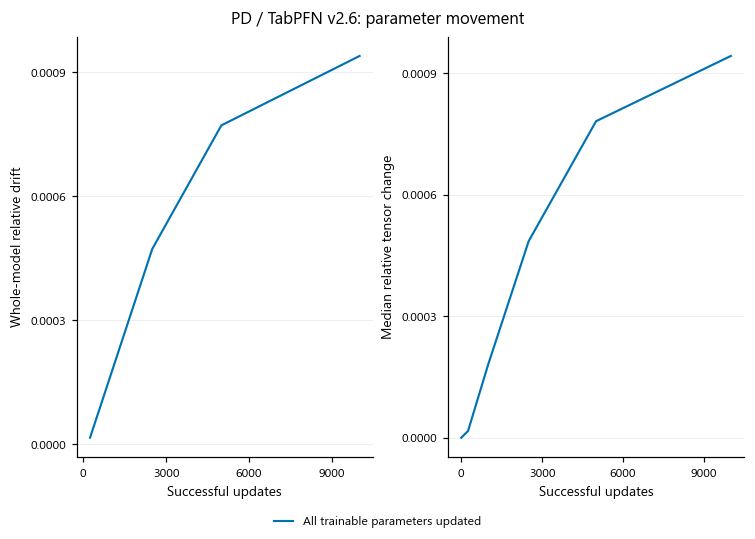

PD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

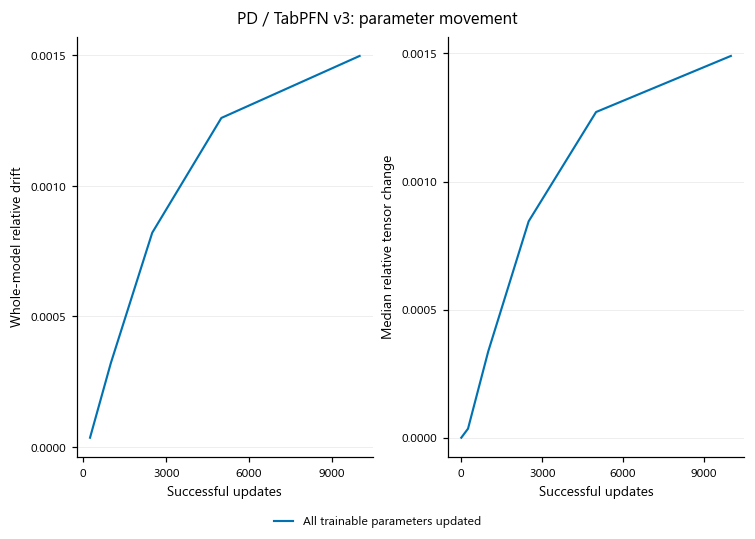

PD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

,base,learning_rate,l2sp_lambda,frozen,sampling,partition,gpu_hours_seed42,rows_seen_seed42,sec_per_step_seed42,peak_gpu_gb_seed42,final_drift_seed42,gpu_hours_seed43,rows_seen_seed43,sec_per_step_seed43,peak_gpu_gb_seed43,final_drift_seed43
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,0.617954,46113629,0.222463,71.895,0.000655,0.624287,46117910,0.224743,71.895,0.000659
1,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,0.868460,49446629,0.312646,89.881,0.004031,0.869703,49451910,0.313093,89.881,0.004025
2,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,0.673445,82784961,0.242440,46.801,0.002386,0.689529,82795244,0.248231,46.801,0.002388
3,TabICLv2,3.000000e-07,0.003,False,one_sample,0,0.642614,82784961,0.231341,10.998,0.001393,0.642462,82795244,0.231286,10.998,0.001385
4,TabPFN v2,3.000000e-07,0.003,False,one_sample,1,0.444908,24755261,0.160167,79.403,0.000688,0.448634,24750304,0.161508,79.403,0.000690
5,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1,0.550625,24755261,0.198225,72.120,0.004137,0.545841,24750304,0.196503,72.120,0.004142
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,1,0.430310,24755261,0.154912,21.665,0.002378,0.442364,24750304,0.159251,21.665,0.002418
7,TabICLv2,3.000000e-07,0.003,False,one_sample,1,0.304217,24755261,0.109518,4.596,0.001245,0.304017,24750304,0.109446,4.596,0.001249
8,TabPFN v2,3.000000e-07,0.003,False,one_sample,2,0.701201,47722903,0.252432,79.403,0.000686,0.699197,47715524,0.251711,79.403,0.000688
9,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,2,0.898289,51056903,0.323384,89.881,0.003871,0.912374,51048524,0.328455,89.881,0.003883


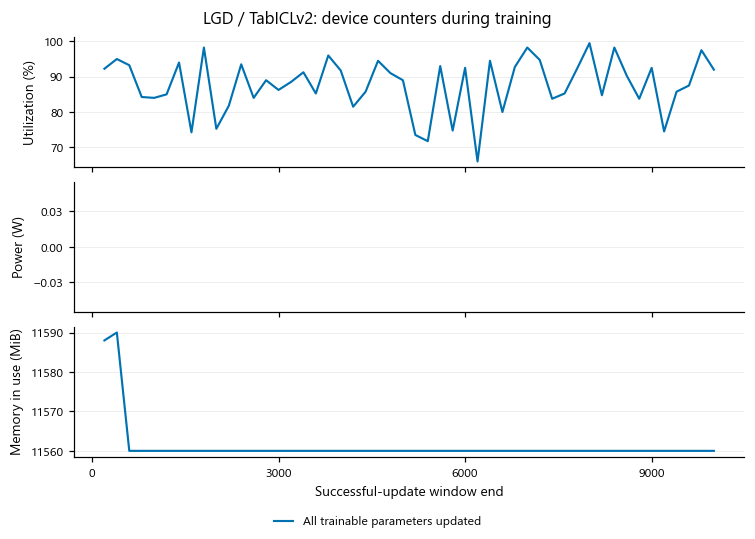

LGD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

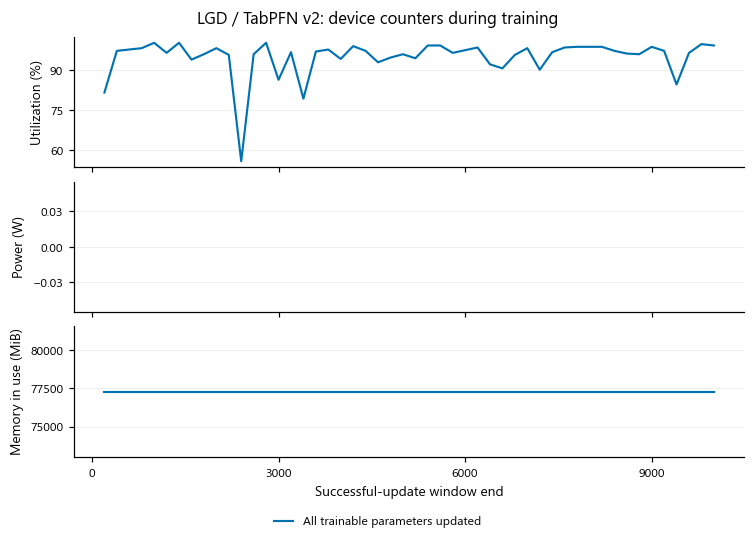

LGD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

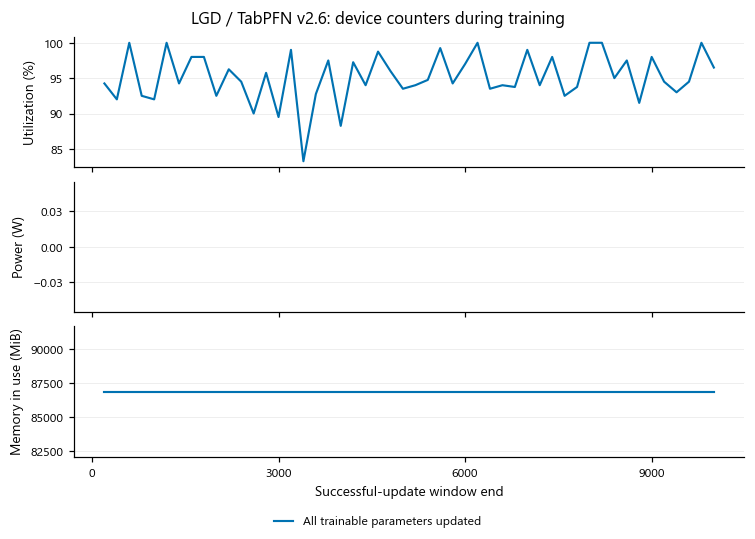

LGD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

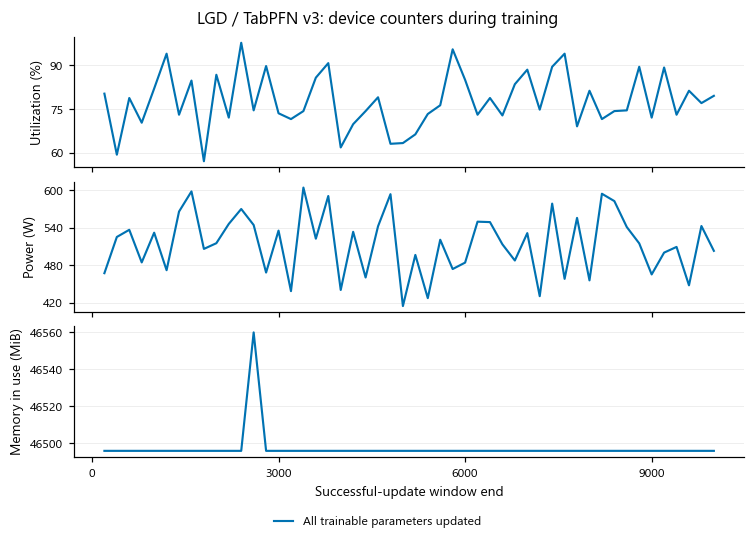

LGD. Sampled training-phase device counters in 200-update windows. Each line is the median of within-trial medians for an adaptation or sampling arm; learning-rate and anchoring recipes are pooled. Counts accompany every window in the text summary. Missing windows remain gaps; changing support can affect the curve. Counters are device-level samples, not integrated energy or billed allocation time.

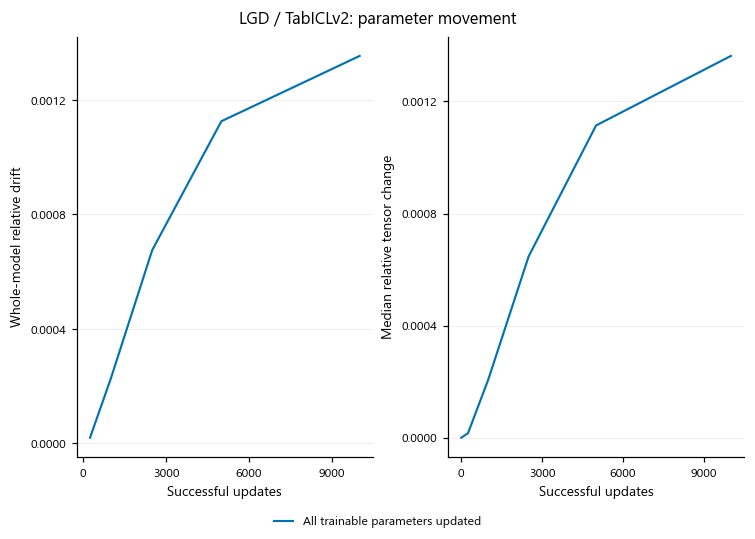

LGD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

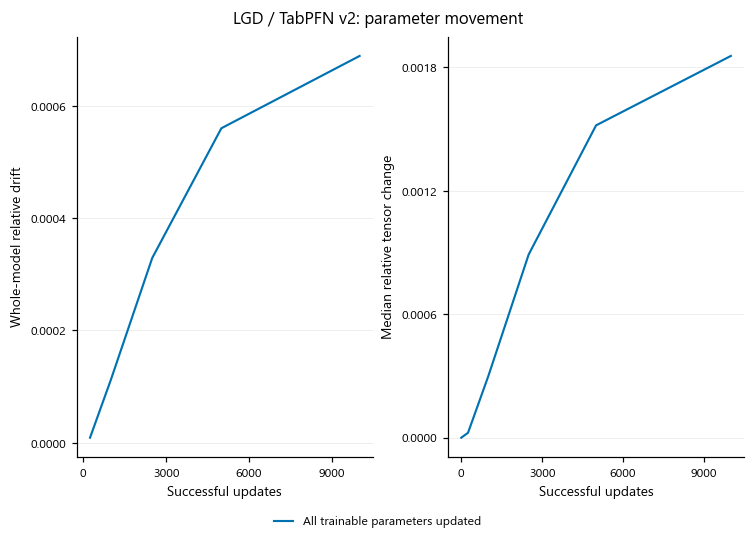

LGD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

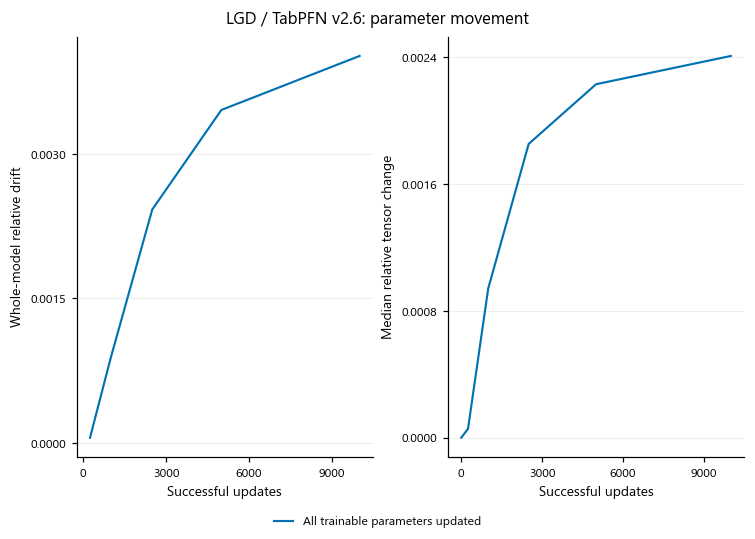

LGD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

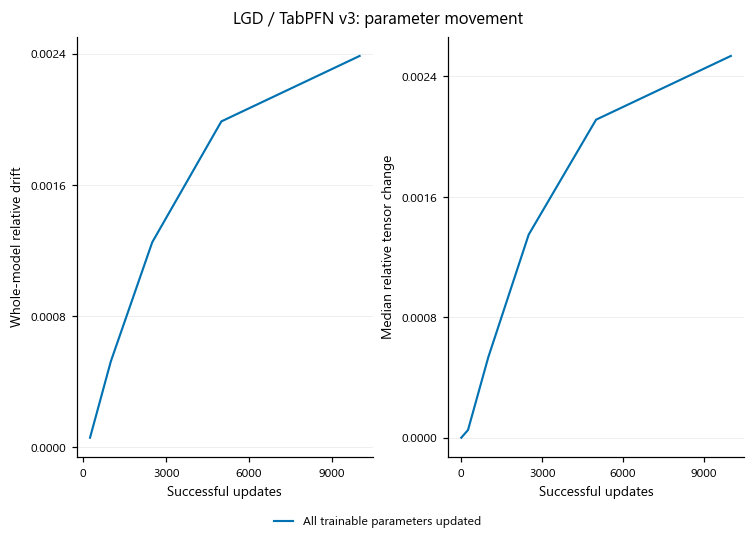

LGD. Complementary summaries of parameter movement. Whole-model drift is norm weighted; tensor movement first takes the median across anchored tensors within a trial. Curves then take medians across available recipes and partitions within each adaptation arm; counts are reported alongside values. Both quantities use their recorded milestones. Changing trial support can affect these descriptive curves.

In [5]:
for track in ('pd','lgd'):
    report.table(track.upper()+' matched seed costs and displacement', cmp.seed_costs(main[track], repeat[track]))
    cp.show(sink, dg.plot_resource_curves(repeat[track]), track=track)
    cp.show(sink, op.plot_movement(repeat[track]), track=track)
report.add('4. Resources and matched training costs', 'Costs match base, recipe and partition. Recorded trial time is not queue time or billed allocation time. Device samples are not integrated energy measurements.')

## Complete text summary

All displayed numerical values and captions, in section order.

In [6]:
print(report.summary(sink))

Experiment 2: seed sensitivity during training

0. Evidence and scope
DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.

1. Reference recipe and training coverage
Seed 42 reuses the predefined main reference; seed 43 has 16 trials per task. Pending status is not live scheduler state.

Table: PD seed 42 reference evidence
           evidence  records                          origin
0    Planned trials       16     Config; not scheduler state
1  Completed trials       16                  DATA manifests
2        Epoch rows    12592    Project training diagnostics
3    Milestone rows       96  Project trajectory diagnostics
4   Benchmark folds      100        Project final evaluation

Table: PD seed 43 evidence
           evidence  records                          origin
0    Planned trials       16     Config; not scheduler state
1  Completed trials       16                  DATA 